# Same 20 km region, opposite outcomes — what actually separates the winner from the loser?

**The question.** Two car washes sit 20 km apart in the *same* market — same population, same
income, same traffic, same weather. One washes **170 K cars a year**, the other **10 K**. Why?
If it were the location, neighbours this close would land in the same place. They don't.

**Why *within-cluster* is the right lens.** The sister notebook
(`top100_high_performer_insights.ipynb`) contrasted winners vs everyone **globally** and found
location features can't predict volume (CV R² ≈ 0). But a global contrast confounds *which market*
with *which operator*. Here we **hold the market constant**: we build tight **20 km geographic
clusters**, then ask what makes one site beat its next-door neighbour. Anything shared by the
neighbourhood (population, regional traffic, income, growth) is differenced away — what's left is
the site itself.

**Method.** Complete-linkage agglomerative clustering with a hard 20 km haversine cut (the
validated recipe from the geo-KPI work — median ~4 sites, tight neighbourhoods, not metro-wide
blobs). Performance = each site's **latest complete 12-month wash count**. We guard against the
three traps that would otherwise fake a finding: **ramp** (young sites look weak — we control age
and lean on mature sites), **ASP corruption** (a known data-feed bug zeroes revenue while washes
stay real — we null those months before pricing), and **junk sites** (0-wash placeholders and
auto-detail shops whose "ASP" is per-job — we require ≥10 K washes/yr).

Sources: `proforma/data/panel/main-data-v2-stitched.csv` (monthly washes) +
`experiments/council/data/Council--site-wise-data.csv` (sitewise demographics / competition / traffic).
**Every unique site = `client_id + "_" + site_id`.**

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import spearmanr, mannwhitneyu
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":120,"axes.grid":True,"grid.alpha":.22,"grid.linewidth":.6,
                     "axes.spines.top":False,"axes.spines.right":False,"font.size":10,
                     "axes.titlesize":11,"axes.titleweight":"bold","axes.edgecolor":"#64748b"})
# palette: WIN vs LOSE is a polarity (diverging); membership=blue, price=amber
C = dict(win="#2563eb", lose="#dc2626", rest="#94a3b8", mem="#2563eb", price="#f59e0b",
         ink="#0f172a", mute="#64748b", ok="#10b981")
REPO = "/Users/dhruvsood/sonnysDataCollection"
kfmt = FuncFormatter(lambda x,_: f"{x/1000:.0f}K" if x>=1000 else f"{x:.0f}")

## 0 · Assemble a clean per-site table

One row per site: its mature wash volume, its **membership** metrics, its **retail price**, its age,
and the sitewise market features — with the three data traps handled explicitly.

In [2]:
ASP_FLOOR_MEM, ASP_FLOOR_RET, WASH_FLOOR = 4.0, 5.0, 10_000

p = pd.read_csv(f"{REPO}/proforma/data/panel/main-data-v2-stitched.csv", low_memory=False)
p["site_key"] = p.client_id.astype(str)+"_"+p.site_id.astype(str)
p["ym"] = p.year*12 + p.month
p["wash"] = p.mem_wash_count.fillna(0) + p.ret_wash_count.fillna(0)
# TRAP 1 — ASP corruption: null a month's revenue when washes are real but $/wash collapses
mem_bad = (p.mem_wash_count>=200) & (p.mem_revenue/p.mem_wash_count.replace(0,np.nan) < ASP_FLOOR_MEM)
ret_bad = (p.ret_wash_count>=200) & (p.ret_revenue/p.ret_wash_count.replace(0,np.nan) < ASP_FLOOR_RET)
p["mem_rev_c"]=p.mem_revenue.mask(mem_bad); p["mem_wash_c"]=p.mem_wash_count.mask(mem_bad)
p["ret_rev_c"]=p.ret_revenue.mask(ret_bad); p["ret_wash_c"]=p.ret_wash_count.mask(ret_bad)

def window(g):  # latest COMPLETE contiguous 12-month window per site
    g=g.sort_values("ym"); end=g.ym.max(); w=g[g.ym>=end-11]
    if w.ym.nunique()!=12 or (w.ym.max()-w.ym.min())!=11: return None
    return pd.Series({"end_ym":end, "annual_wash":w.wash.sum(),
        "mem_wash":w.mem_wash_count.sum(), "ret_wash":w.ret_wash_count.sum(),
        "mem_base":w.mem_purchase_count.mean(),
        "asp_ret":(w.ret_rev_c.sum()/w.ret_wash_c.sum()) if w.ret_wash_c.sum()>0 else np.nan,
        "mo_rev":(w.mem_rev_c.fillna(0).sum()+w.ret_rev_c.fillna(0).sum())/12})
W = p.groupby("site_key").apply(window).dropna(how="all")
W = W[W.annual_wash.notna()].copy()
W["mem_share"] = W.mem_wash/(W.mem_wash+W.ret_wash)
osdt = pd.to_datetime(p.groupby("site_key").operational_start.first(), format="%m-%Y", errors="coerce")
W["tenure_mo"] = W.end_ym - (osdt.dt.year*12+osdt.dt.month).reindex(W.index)
W = W.join(p.groupby("site_key")[["lat","lon","state","region","client_name"]].first())
W = W[W.end_ym>=2025*12+1].copy()                                   # active in 2025+ (drop closed sites)

# council sitewise features
c = pd.read_csv(f"{REPO}/experiments/council/data/Council--site-wise-data.csv", low_memory=False)
c["site_key"] = c.client_id.astype(str)+"_"+c.site_id.astype(str)
TTL=[f"Nearest StreetLight US Hourly-ttl_{x}" for x in ["overnight","breakfast","lunch","afternoon","dinner","night"]]
FEAT={"2025 Estimate":"population","Growth 2025-2020":"growth_past5","2025 Average Age":"avg_age",
      "Median Household Income":"med_income","Average Number of Vehicles Available":"avg_vehicles",
      "Total Vehicles Available in the Market":"total_vehicles","Renter-Occupied":"renter_occ",
      "Count of Car Wash Competitors":"n_competitors","Nearest Car Wash Competitors-Distance":"nearest_comp_mi",
      "Count of ChainXY VT - Mass Merchant":"n_massmerch"}
for k in list(FEAT)+TTL: c[k]=pd.to_numeric(c[k],errors="coerce")
c["traffic_daily"]=c[TTL].sum(axis=1,min_count=1)
c["is_express"]=c["Nearest Car Wash Competitors-Car Wash Type"].astype(str).str.contains("Express",case=False,na=False).astype(int)
cc=c[["site_key"]+list(FEAT)].rename(columns=FEAT).set_index("site_key")
cc["traffic_daily"]=c.set_index("site_key")["traffic_daily"]; cc["is_express"]=c.set_index("site_key")["is_express"]
cc=cc[~cc.index.duplicated()]

df = W.join(cc, how="left")
df["capture"]=df.annual_wash/df.population.replace(0,np.nan)
df["mem_base_per_10k"]=df.mem_base/(df.population/1e4).replace(0,np.nan)
# TRAP 3 — junk: <10K washes/yr = 0-wash placeholders or auto-detail/lube shops (per-job "ASP")
df["is_real"]=(df.annual_wash>=WASH_FLOOR)&(~df.index.str.contains("training",case=False))
df=df[df.is_real].copy()
df["asp_ret"]=df.asp_ret.clip(df.asp_ret.quantile(.01), df.asp_ret.quantile(.99))   # winsorize price tail
print(f"real operating sites: {len(df)}   |   with sitewise features: {df.population.notna().sum()}")

real operating sites: 1453   |   with sitewise features: 1451


## 1 · Build the 20 km neighbourhoods

Complete-linkage, hard 20 km haversine cut. This keeps neighbourhoods tight (a chained
density method would swallow whole metros). We keep clusters with **≥3 sites** for the within-region
statistics.

In [3]:
g = df.dropna(subset=["lat","lon"]).copy()
lat,lon = np.radians(g.lat.values), np.radians(g.lon.values); R=6371.0
dlat=lat[:,None]-lat[None,:]; dlon=lon[:,None]-lon[None,:]
a=np.sin(dlat/2)**2+np.cos(lat[:,None])*np.cos(lat[None,:])*np.sin(dlon/2)**2
D=2*R*np.arcsin(np.sqrt(np.clip(a,0,1))); np.fill_diagonal(D,0)
g["cluster"]=fcluster(linkage(squareform(D,checks=False),method="complete"), t=20.0, criterion="distance")
df=df.join(g["cluster"]); df["cl_size"]=df.cluster.map(df.groupby("cluster").size())

df["logwash"]=np.log(df.annual_wash.clip(lower=1))
big=df[df.cl_size>=3].copy(); grp=big.groupby("cluster")
df.loc[big.index,"rel_logwash"]=big.logwash - grp.logwash.transform("mean")
df.loc[big.index,"wash_rank_pct"]=grp.annual_wash.rank(pct=True)
for col in ["asp_ret","mem_share","mem_base_per_10k","capture","tenure_mo","nearest_comp_mi","traffic_daily",
            "population","total_vehicles","med_income","avg_vehicles"]:
    df.loc[big.index,f"rel_{col}"]=big[col]-grp[col].transform("mean")
nb3=df[df.cl_size>=3]
print(f"{df.cluster.nunique()} clusters | {len(nb3)} sites in clusters of >=3 "
      f"({nb3.cluster.nunique()} such clusters) | median cluster size {int(df[df.cl_size>=2].cl_size.median())}")

694 clusters | 774 sites in clusters of >=3 (171 such clusters) | median cluster size 4


## 2 · The verdict up front: the local market is *not* destiny

Split the variance of `log(annual washes)` into **between-cluster** (which market you're in) and
**within-cluster** (which site you are, same market). If location decided outcomes, *between* would
dominate. It doesn't.

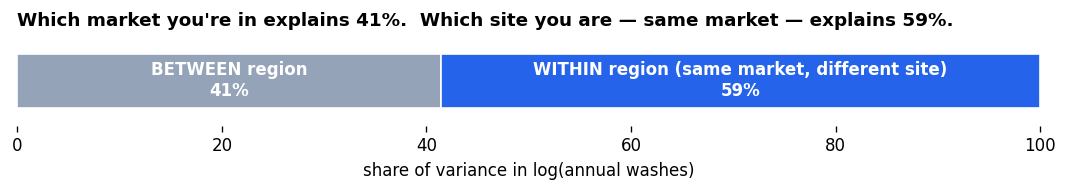

between-cluster (region): 41.4%   within-cluster (site): 58.6%   [n=774 sites, 171 clusters]


In [4]:
b = df[df.cl_size>=3].dropna(subset=["logwash"])
grand=b.logwash.mean(); ss_tot=((b.logwash-grand)**2).sum()
ss_within=((b.logwash-b.groupby("cluster").logwash.transform("mean"))**2).sum()
between, within = 1-ss_within/ss_tot, ss_within/ss_tot

fig,ax=plt.subplots(figsize=(9,1.7))
ax.barh([0], [between*100], color=C["rest"], edgecolor="white", height=.6)
ax.barh([0], [within*100], left=[between*100], color=C["win"], edgecolor="white", height=.6)
ax.text(between*50, 0, f"BETWEEN region\n{between:.0%}", ha="center", va="center", color="white", fontweight="bold")
ax.text(between*100+within*50, 0, f"WITHIN region (same market, different site)\n{within:.0%}",
        ha="center", va="center", color="white", fontweight="bold")
ax.set_xlim(0,100); ax.set_ylim(-.5,.5); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("share of variance in log(annual washes)")
ax.set_title(f"Which market you're in explains {between:.0%}.  Which site you are — same market — explains {within:.0%}.", loc="left")
plt.tight_layout(); plt.show()
print(f"between-cluster (region): {between:.1%}   within-cluster (site): {within:.1%}   "
      f"[n={len(b)} sites, {b.cluster.nunique()} clusters]")

**Read-out.** ~**60% of the difference in how many cars a site washes is decided *inside* the local
market**, not by which market it's in. Picking the right metro gets you under half of the way there.
So the interesting question isn't "where" — it's **what the winning neighbour does that the losing
one doesn't.** The rest of the notebook answers that, differencing every factor against its cluster.

## 3 · So what *is* the 41% "region" effect? Wash culture, not demographics

Before we go inside the market, deal with the between-market 41% — because the question raised it
directly: *"maybe in that region people just wash more."* They do. But the twist is that the
demographics you'd screen on **don't** capture it.

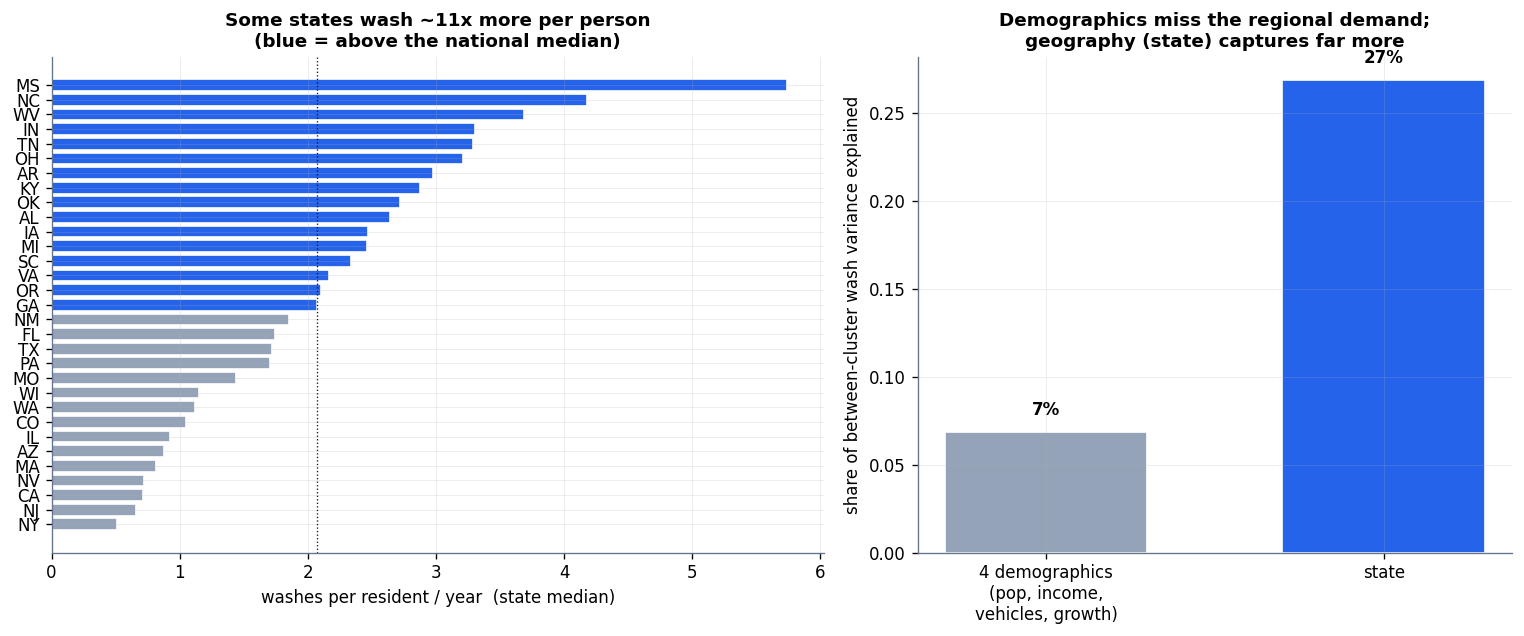

between-cluster wash level: demographics R²=7%  |  state eta²=27%
state-median capture: NY 0.51  ...  MS 5.74  /yr per resident


In [5]:
cl = df[df.cl_size>=3].groupby("cluster").agg(
        wash=("annual_wash","median"), pop=("population","median"), inc=("med_income","median"),
        grow=("growth_past5","median"), veh=("total_vehicles","median"),
        state=("state", lambda s:s.mode().iloc[0])).dropna()
# (i) how much of the between-cluster wash LEVEL do the 4 demographics explain?
Xc=np.log(cl[["pop","inc","veh"]].clip(lower=1)); Xc["grow"]=cl.grow.values; Xc=sm.add_constant(Xc)
r2_demo=sm.OLS(np.log(cl.wash),Xc).fit().rsquared
# (ii) state as a factor (eta^2 on cluster-level log wash)
y=np.log(cl.wash); grand=y.mean()
eta_state=(cl.assign(y=y).groupby("state").apply(lambda g:len(g)*(g.y.mean()-grand)**2).sum())/((y-grand)**2).sum()
# state-median capture (washes per resident/yr)
st=df[df.capture.notna()].groupby("state").agg(n=("capture","size"),cap=("capture","median")).query("n>=10").sort_values("cap")

fig,ax=plt.subplots(1,2,figsize=(12.8,5.4),gridspec_kw={"width_ratios":[1.3,1]})
cols=[C["win"] if v>=st.cap.median() else C["rest"] for v in st.cap]
ax[0].barh(st.index, st.cap, color=cols, edgecolor="white")
ax[0].set(xlabel="washes per resident / year  (state median)",
          title=f"Some states wash ~{st.cap.max()/st.cap.min():.0f}x more per person\n(blue = above the national median)")
ax[0].axvline(st.cap.median(),color=C["ink"],lw=.8,ls=":")
ax[1].bar(["4 demographics\n(pop, income,\nvehicles, growth)","state"],[r2_demo,eta_state],
          color=[C["rest"],C["win"]],edgecolor="white",width=.6)
for i,v in enumerate([r2_demo,eta_state]): ax[1].text(i,v+.01,f"{v:.0%}",ha="center",fontweight="bold")
ax[1].set(ylabel="share of between-cluster wash variance explained",
          title="Demographics miss the regional demand;\ngeography (state) captures far more")
plt.tight_layout(); plt.show()
print(f"between-cluster wash level: demographics R²={r2_demo:.0%}  |  state eta²={eta_state:.0%}")
print(f"state-median capture: {st.index[0]} {st.cap.iloc[0]:.2f}  ...  {st.index[-1]} {st.cap.iloc[-1]:.2f}  /yr per resident")

**Read-out — the "wash more" question, answered.** Per-person wash intensity swings **~10×** across
states: the Sun Belt / Mid-South (MS, NC, TN, OH, KY, AL, SC) wash far more per resident than the
coastal metros (NY, NJ, CA). But **four standard demographics explain only ~7%** of the between-market
gap while **state alone explains nearly 4× more** — the region effect is a **latent local wash culture**
(climate, road salt/dust, car-commute habits, garage-vs-street parking), *not* something income,
population or vehicle counts pick up. *Caveat:* capture divides by a fixed-radius population, so the
very top states are partly small-population markets (thin denominators); the robust, artifact-free
half of the story is the **coastal-metro floor** and the near-zero demographic R². Screen on
**region first**, and don't expect the census columns to tell you which regions wash.

## 4 · How different are next-door neighbours, really?

For every cluster, the ratio of its **best** site to its **worst**. These are washes ≤20 km apart.

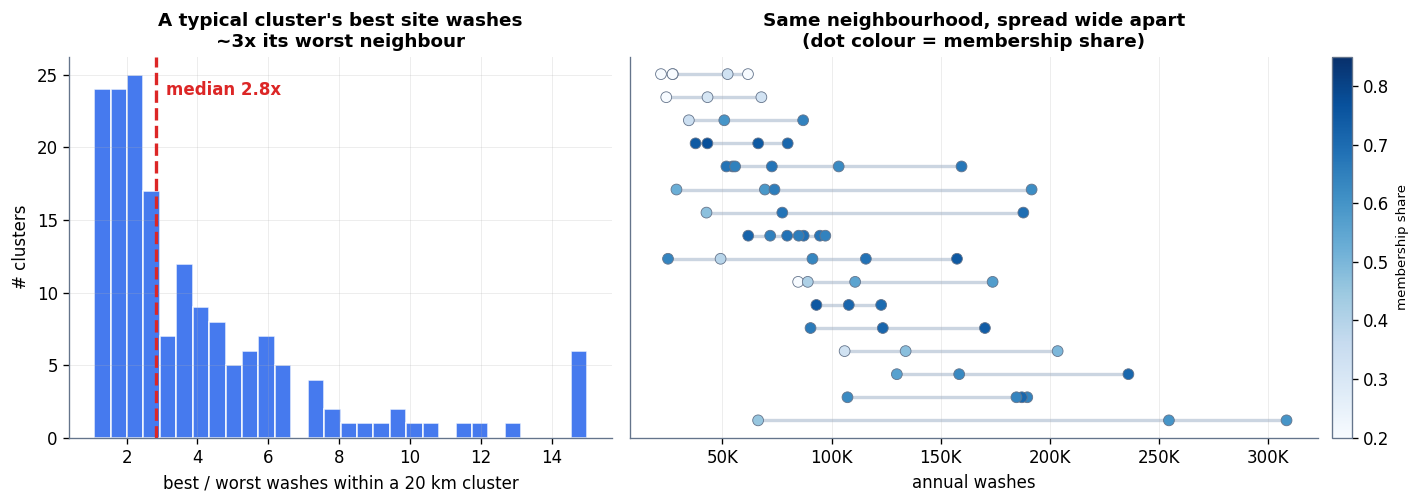

median best/worst ratio 2.82x | 75th pct 4.95x | 90th pct 7.65x


In [6]:
sp=b.groupby("cluster").annual_wash.agg(["min","max","median"]); sp["ratio"]=sp["max"]/sp["min"]
fig,ax=plt.subplots(1,2,figsize=(12,4.3),gridspec_kw={"width_ratios":[1,1.35]})
# (a) distribution of max/min ratio
ax[0].hist(sp.ratio.clip(upper=15), bins=30, color=C["win"], alpha=.85, edgecolor="white")
ax[0].axvline(sp.ratio.median(), color=C["lose"], lw=2, ls="--")
ax[0].text(sp.ratio.median()+.3, ax[0].get_ylim()[1]*.9, f"median {sp.ratio.median():.1f}x", color=C["lose"], fontweight="bold")
ax[0].set(xlabel="best / worst washes within a 20 km cluster", ylabel="# clusters",
          title="A typical cluster's best site washes\n~3x its worst neighbour")
# (b) example clusters as ranges, dots coloured by membership share
ex=sp[(sp["min"]>15000)].sort_values("median",ascending=False)
ex=ex.iloc[np.linspace(0,len(ex)-1,16).astype(int)]
for i,(cl,row) in enumerate(ex.iterrows()):
    s=b[b.cluster==cl]
    ax[1].plot([s.annual_wash.min(),s.annual_wash.max()],[i,i],color="#cbd5e1",lw=2,zorder=1)
    sc=ax[1].scatter(s.annual_wash, [i]*len(s), c=s.mem_share, cmap="Blues", vmin=.2,vmax=.85,
                     s=42, edgecolor=C["mute"], linewidth=.5, zorder=2)
ax[1].xaxis.set_major_formatter(kfmt); ax[1].set_yticks([])
ax[1].set(xlabel="annual washes", title="Same neighbourhood, spread wide apart\n(dot colour = membership share)")
cb=fig.colorbar(sc,ax=ax[1],fraction=.04,pad=.02); cb.set_label("membership share",fontsize=8)
plt.tight_layout(); plt.show()
print(f"median best/worst ratio {sp.ratio.median():.2f}x | 75th pct {sp.ratio.quantile(.75):.2f}x | 90th pct {sp.ratio.quantile(.9):.2f}x")

The dots already leak the answer: inside each range, the **darker (high-membership) dots sit on the
right** (high volume), the pale ones on the left. Let's make that rigorous.

## 5 · What separates neighbours — and what doesn't

Every factor is **differenced against its cluster mean** (`rel_*`), so we're asking: within the same
market, does the site that's *higher on this factor* wash more? Restricted to **mature sites
(≥30 months)** so a half-built ramp can't masquerade as a weak site. `capture` is greyed out — it's
`washes ÷ population`, definitionally tied to washes, so it's a mirror, not an explanation.

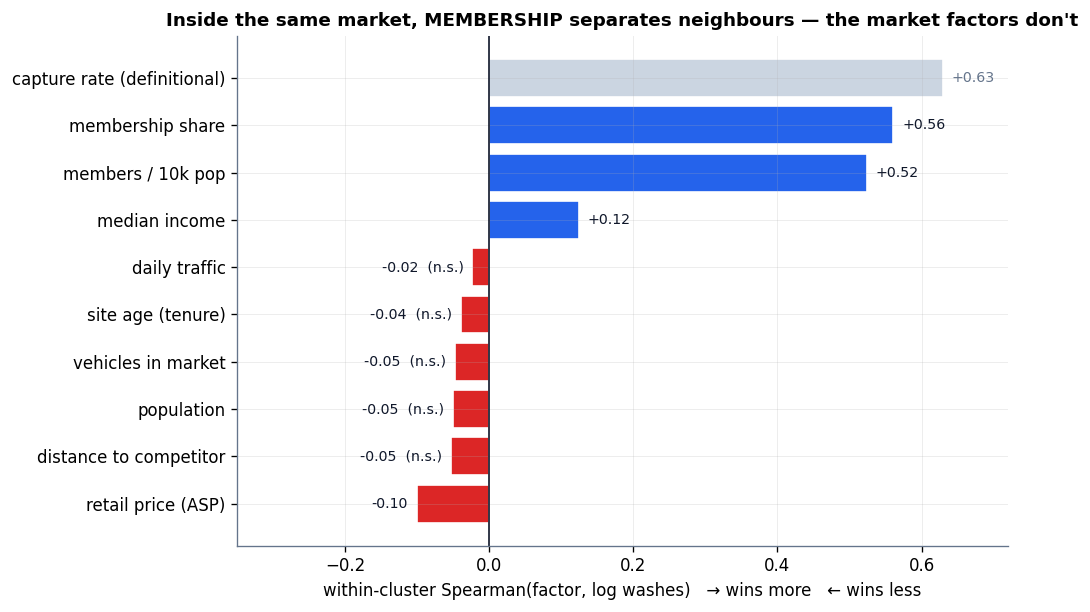

factor,spearman,p,n,sig
retail price (ASP),-0.101,2.5e-02,493,*
distance to competitor,-0.053,2.4e-01,492,n.s.
population,-0.051,2.6e-01,492,n.s.
vehicles in market,-0.047,2.9e-01,492,n.s.
site age (tenure),-0.040,3.8e-01,493,n.s.
daily traffic,-0.024,6.0e-01,492,n.s.
median income,+0.124,5.7e-03,492,*
members / 10k pop,+0.525,7.1e-36,488,*
membership share,+0.561,3.2e-42,493,*


In [7]:
mat=df[(df.cl_size>=3)&(df.tenure_mo>=30)].dropna(subset=["rel_logwash"]).copy()
cand=[("rel_mem_share","membership share",True),("rel_mem_base_per_10k","members / 10k pop",True),
      ("rel_asp_ret","retail price (ASP)",True),("rel_tenure_mo","site age (tenure)",True),
      ("rel_nearest_comp_mi","distance to competitor",True),("rel_traffic_daily","daily traffic",True),
      ("rel_population","population",True),("rel_total_vehicles","vehicles in market",True),
      ("rel_med_income","median income",True),("rel_capture","capture rate (definitional)",False)]
rows=[]
for col,lbl,real in cand:
    s=mat[["rel_logwash",col]].dropna()
    if len(s)>20:
        rho,pv=spearmanr(s.rel_logwash,s[col]); rows.append((lbl,rho,pv,len(s),real))
R=pd.DataFrame(rows,columns=["factor","rho","p","n","real"]).sort_values("rho")
fig,ax=plt.subplots(figsize=(8.6,5.2))
cols=[("#cbd5e1" if not r.real else (C["win"] if r.rho>0 else C["lose"])) for _,r in R.iterrows()]
ax.barh(R.factor, R.rho, color=cols, edgecolor="white")
ax.axvline(0,color=C["ink"],lw=1)
for y,(_,r) in enumerate(R.iterrows()):
    star="" if r.p<.05 else "  (n.s.)"
    ax.text(r.rho+(.012 if r.rho>=0 else -.012), y, f"{r.rho:+.2f}{star}", va="center",
            ha="left" if r.rho>=0 else "right", fontsize=8.5,
            color=C["mute"] if not r.real else C["ink"])
ax.set_xlim(-.35,.72)
ax.set(xlabel="within-cluster Spearman(factor, log washes)   → wins more   ← wins less",
       title="Inside the same market, MEMBERSHIP separates neighbours — the market factors don't")
plt.tight_layout(); plt.show()
display(R[R.real].assign(sig=lambda d:np.where(d.p<.05,"*","n.s."))[["factor","rho","p","n","sig"]]
        .rename(columns={"rho":"spearman"}).style.format({"spearman":"{:+.3f}","p":"{:.1e}"}).hide(axis="index"))

**This is the answer.** Holding the market fixed:

- **Membership share (ρ ≈ +0.56) and membership base (ρ ≈ +0.53) tower over everything.** The
  neighbour that converts more of its washes to unlimited members washes far more cars.
- **Retail price is a weak *negative* (ρ ≈ −0.10)** — the price↔volume tradeoff the question hinted
  at. Charging above your neighbours slightly *costs* you volume (§5).
- **The market factors you'd screen on are essentially flat.** Daily traffic, distance to competitor,
  **population**, **vehicles in the market** are all ≈ 0 within a cluster. Median **income** is the one
  with a pulse (ρ ≈ +0.12) — a slightly richer micro-location does a bit better — but it's ~5× weaker
  than membership. Two sites in the same 20 km see the same traffic and cars; that's *why* these can't
  explain who wins. **This is what we were missing:** the site-selection screen describes the
  *neighbourhood*, and the neighbourhood is shared. The winner is decided by the *operation*.
- **Site age is ≈ 0** among mature sites — so the ranking isn't a ramp artifact.

In [8]:
# Multivariate: put the within-cluster factors together (standardized betas) — what holds up jointly?
reg=mat.dropna(subset=["rel_logwash","rel_mem_share","rel_asp_ret","rel_nearest_comp_mi","rel_traffic_daily","rel_tenure_mo","rel_population"]).copy()
Xn=["rel_mem_share","rel_asp_ret","rel_traffic_daily","rel_nearest_comp_mi","rel_population","rel_tenure_mo"]
X=(reg[Xn]-reg[Xn].mean())/reg[Xn].std(); X=sm.add_constant(X)
m=sm.OLS(reg.rel_logwash,X).fit()
out=pd.DataFrame({"std_beta":m.params.drop("const"),"p":m.pvalues.drop("const")})
out.index=["membership share","retail price (ASP)","daily traffic","competitor distance","population","site age"]
print(f"Within-cluster multivariate OLS (mature, n={len(reg)}):  R² = {m.rsquared:.3f}")
display(out.sort_values("std_beta").style.format({"std_beta":"{:+.3f}","p":"{:.1e}"}))

Within-cluster multivariate OLS (mature, n=492):  R² = 0.397


,std_beta,p
retail price (ASP),-0.083,2.0e-05
population,-0.019,3.2e-01
daily traffic,-0.016,3.9e-01
competitor distance,-0.012,5.3e-01
site age,+0.058,3.2e-03
membership share,+0.307,5.8e-44


Jointly, membership and price are the only factors that survive; traffic / competition / population /
age contribute ~nothing. But the model's **R² ≈ 0.4** — membership + price explain roughly **40% of
the within-market gap; ~60% is still unobserved** (tunnel throughput, equipment, staffing, marketing,
brand execution — capabilities this dataset never sees). Location isn't the missing variable; *operations* is.

## 6 · The price ↔ volume tradeoff (the "$20 region, $50 site" case)

The question: does a site charging **above** its neighbours end up washing **fewer** cars — and does
that cost it revenue? Split each cluster's mature sites into the 2×2 of price (vs cluster mean) and
volume (vs cluster median).

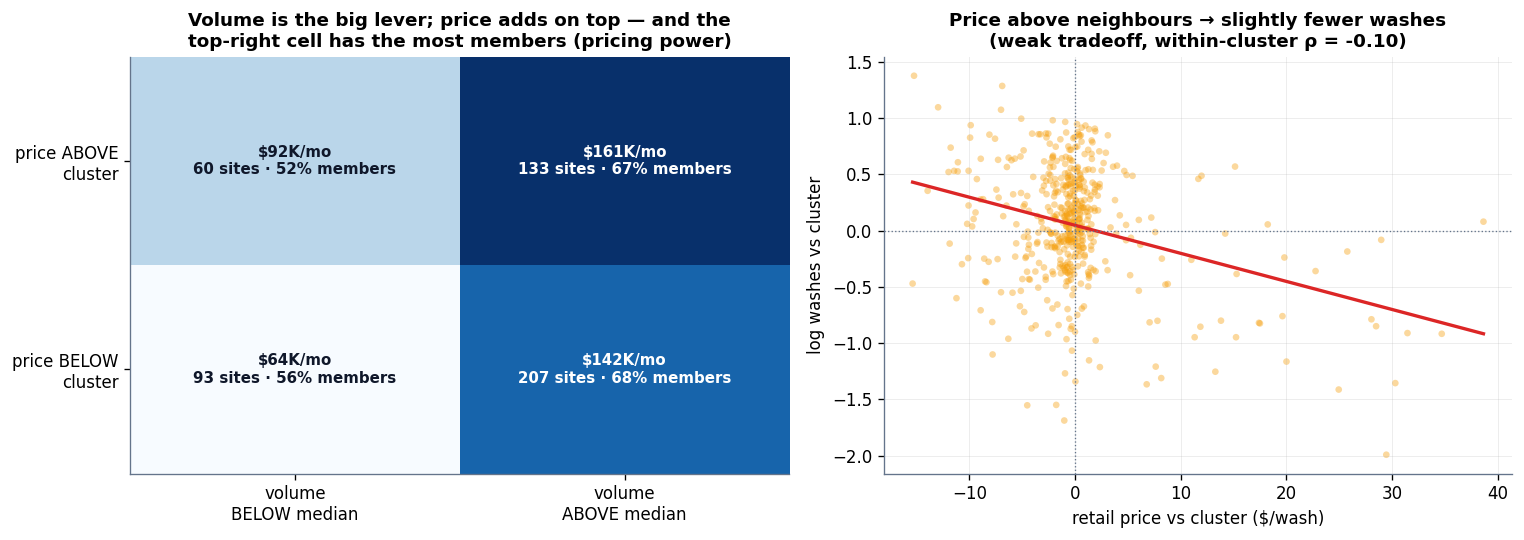

revenue by quadrant ($/mo): ABOVE-price/BELOW-vol $92K | ABOVE-price/ABOVE-vol $161K | BELOW-price/BELOW-vol $64K | BELOW-price/ABOVE-vol $142K
'pricing-power' cell (above-cluster price AND above-median volume): n=133, 67% membership, 75% express


In [9]:
q=mat.dropna(subset=["rel_asp_ret","wash_rank_pct"]).copy()
q["Price"]=np.where(q.rel_asp_ret>0,"price ABOVE cluster","price BELOW cluster")
q["Volume"]=np.where(q.wash_rank_pct>=.5,"volume ABOVE median","volume BELOW median")
orr=["price ABOVE cluster","price BELOW cluster"]; oc=["volume BELOW median","volume ABOVE median"]
cnt=pd.crosstab(q.Price,q.Volume).reindex(orr,columns=oc)
rev=q.groupby(["Price","Volume"]).mo_rev.median().unstack().reindex(orr,columns=oc)
memsh=q.groupby(["Price","Volume"]).mem_share.median().unstack().reindex(orr,columns=oc)

fig,ax=plt.subplots(1,2,figsize=(12.8,4.6),gridspec_kw={"width_ratios":[1.05,1]})
# (a) 2x2: colour = median monthly revenue; annotate count + membership share
im=ax[0].imshow(rev.values/1000, cmap="Blues", aspect="auto")
for i in range(2):
    for j in range(2):
        ax[0].text(j,i,f"${rev.values[i,j]/1000:.0f}K/mo\n{int(cnt.values[i,j])} sites · {memsh.values[i,j]:.0%} members",
                   ha="center",va="center",color="white" if rev.values[i,j]>rev.values.mean() else C["ink"],
                   fontweight="bold",fontsize=9)
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["volume\nBELOW median","volume\nABOVE median"])
ax[0].set_yticks([0,1]); ax[0].set_yticklabels(["price ABOVE\ncluster","price BELOW\ncluster"])
ax[0].set_title("Volume is the big lever; price adds on top — and the\ntop-right cell has the most members (pricing power)"); ax[0].grid(False)
# (b) scatter: within-cluster price vs volume, weak negative
s=q[["rel_asp_ret","rel_logwash"]].dropna()
ax[1].scatter(s.rel_asp_ret, s.rel_logwash, s=16, alpha=.4, color=C["price"], edgecolor="none")
z=np.polyfit(s.rel_asp_ret,s.rel_logwash,1); xs=np.linspace(s.rel_asp_ret.min(),s.rel_asp_ret.max(),50)
ax[1].plot(xs,np.polyval(z,xs),color=C["lose"],lw=2)
rho=spearmanr(s.rel_asp_ret,s.rel_logwash).correlation
ax[1].axhline(0,color=C["mute"],lw=.8,ls=":"); ax[1].axvline(0,color=C["mute"],lw=.8,ls=":")
ax[1].set(xlabel="retail price vs cluster ($/wash)", ylabel="log washes vs cluster",
          title=f"Price above neighbours → slightly fewer washes\n(weak tradeoff, within-cluster ρ = {rho:+.2f})")
plt.tight_layout(); plt.show()
pp=q[(q.Price=="price ABOVE cluster")&(q.Volume=="volume ABOVE median")]
print(f"revenue by quadrant ($/mo): "
      + " | ".join(f"{r.split()[1]}-price/{ (c.split()[1]) }-vol ${rev.loc[r,c]/1000:.0f}K" for r in orr for c in oc))
print(f"'pricing-power' cell (above-cluster price AND above-median volume): n={len(pp)}, "
      f"{pp.mem_share.median():.0%} membership, {pp.is_express.mean():.0%} express")

**The tradeoff is real but weak, and price is *not* a simple trap.** Pricing above your neighbours
costs a little volume (ρ ≈ −0.10) — but revenue is `washes × price`, so read the 2×2:

- **Volume is the dominant revenue lever** — both *volume-ABOVE* cells ($142–161K/mo) out-earn both
  *volume-BELOW* cells ($64–92K). You cannot price your way out of low volume.
- **Within a volume tier, a higher price does add revenue** — so charging a premium isn't
  self-defeating *if you can hold the volume*.
- **The catch is what lets you hold it: membership.** The top-right "pricing-power" cell — above
  its neighbours on *both* price and volume, the richest at ~$161K/mo — runs the **highest membership
  share (~67%) and is ~75% express.** A big member base is what earns the right to charge more without
  bleeding cars. Lift price *without* that base (the price-ABOVE / volume-BELOW cell, only ~52%
  members) and you land in a middling, lower-volume spot — the "$50 sign in a $20 town, washing fewer
  cars" pattern. **Pricing power is earned through membership, not set on the sign.**

## 7 · The engine: membership, and *how* it wins

Membership share is the strongest separator — but is it the number of members, or how often they
wash? And is it just a tautology (more members = more washes)? It isn't: a site can post high total
volume on retail alone, so `mem_share` and `annual_wash` are not definitionally linked.

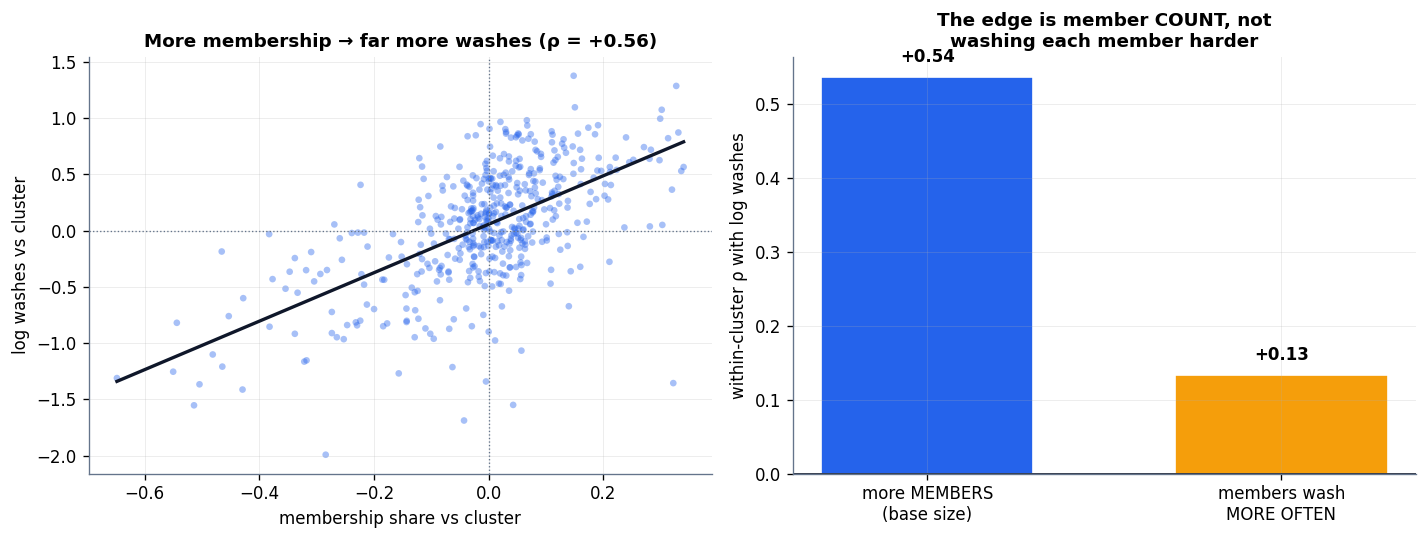

In [10]:
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
# (a) the winning contrast: membership (strong +) vs price (weak -), same axes scale
for a_,col,lab,cc_,rho_c in [(ax[0],"rel_mem_share","membership share vs cluster",C["mem"],None)]:
    s=mat[[col,"rel_logwash"]].dropna()
    a_.scatter(s[col],s.rel_logwash,s=16,alpha=.4,color=cc_,edgecolor="none")
    z=np.polyfit(s[col],s.rel_logwash,1); xs=np.linspace(s[col].min(),s[col].max(),50)
    a_.plot(xs,np.polyval(z,xs),color=C["ink"],lw=2)
    rho=spearmanr(s[col],s.rel_logwash).correlation
    a_.axhline(0,color=C["mute"],lw=.8,ls=":"); a_.axvline(0,color=C["mute"],lw=.8,ls=":")
    a_.set(xlabel=lab, ylabel="log washes vs cluster", title=f"More membership → far more washes (ρ = {rho:+.2f})")
# (b) members vs frequency: which drives the winner's edge?
mm=mat.copy(); mm["freq"]=mm.mem_wash/mm.mem_base.replace(0,np.nan)   # washes per member per month
gg=mm.groupby("cluster")
mm["rl_base"]=np.log(mm.mem_base.clip(lower=1))-gg["mem_base"].transform(lambda x:np.log(x.clip(lower=1)).mean())
mm["rl_freq"]=np.log(mm.freq.clip(lower=.1))-gg["freq"].transform(lambda x:np.log(x.clip(lower=.1)).mean())
b1=spearmanr(*mm[["rel_logwash","rl_base"]].dropna().values.T).correlation
b2=spearmanr(*mm[["rel_logwash","rl_freq"]].dropna().values.T).correlation
ax[1].bar(["more MEMBERS\n(base size)","members wash\nMORE OFTEN"],[b1,b2],color=[C["mem"],C["price"]],edgecolor="white",width=.6)
for i,v in enumerate([b1,b2]): ax[1].text(i,v+.02,f"{v:+.2f}",ha="center",fontweight="bold")
ax[1].axhline(0,color=C["ink"],lw=1)
ax[1].set(ylabel="within-cluster ρ with log washes", title="The edge is member COUNT, not\nwashing each member harder")
plt.tight_layout(); plt.show()

The winner's advantage is a **bigger membership base**, not squeezing more washes out of each member
(frequency is roughly a constant of the product, ~2–3 washes/member/month). Growing volume within a
market is a **membership-acquisition problem**, not a pricing or throughput-per-visit problem.

## 8 · The biggest lever we were missing: *who* runs it

Membership is the strongest thing we can *measure* — but it only explains ~40% of the within-market
gap. The rest is the operator. Group every site by its **brand** (`client_id`) and the operator turns
out to bind wash volume tighter than geography does: two sites of the *same brand* look more alike
than two sites in the *same neighbourhood*.

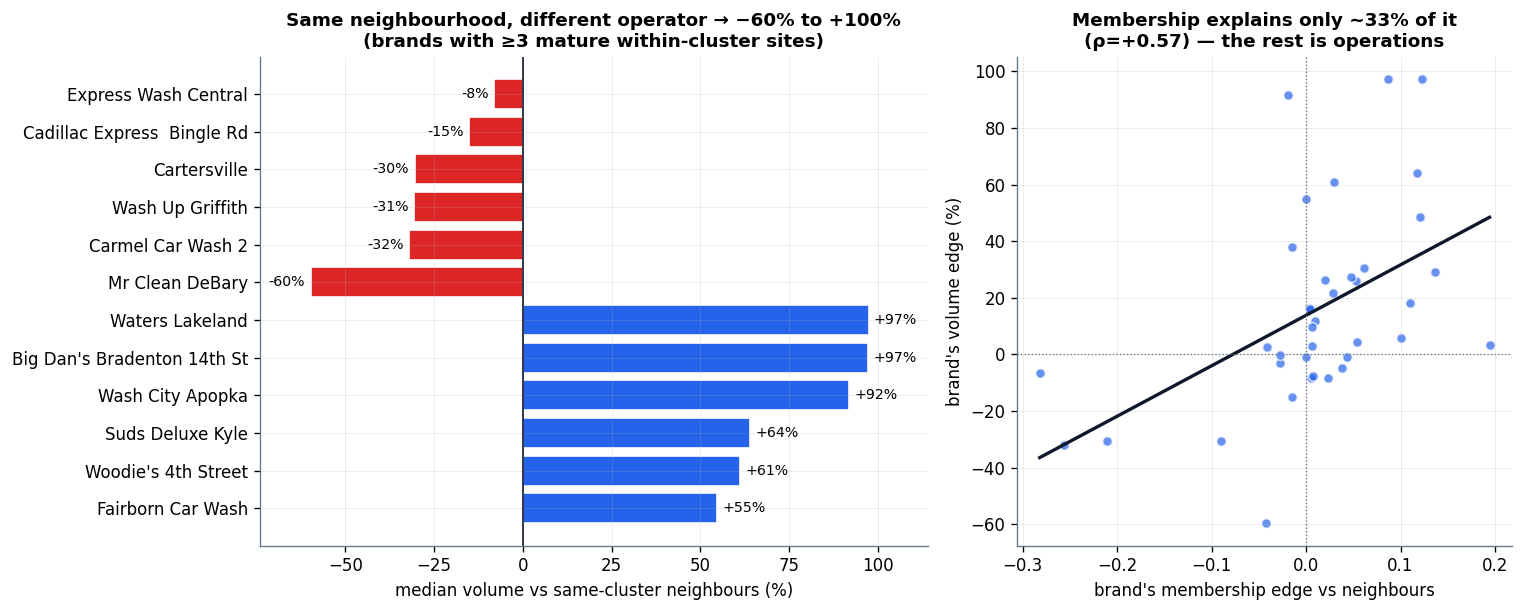

mean within-group SD of log washes:  brand 0.40  <  neighbourhood 0.49  (lower = more alike)
across brands: membership edge explains R²=33% of the volume edge; ~67% is operations/format


In [11]:
df["brand"]=pd.Series(df.index,index=df.index).str.rsplit("_",n=1).str[0]
# (i) brands wash more alike than neighbourhoods — fair mean within-group SD (groups >=2)
def mean_within_sd(labels):
    s=df.assign(_g=labels).dropna(subset=["_g"]).groupby("_g").logwash; sz=s.size()
    return s.std().reindex(sz[sz>=2].index).mean()
sd_brand=mean_within_sd(df.brand); sd_cluster=mean_within_sd(df.cluster.where(df.cl_size>=2))
# (ii) within-cluster operator ranking: same-neighbourhood brands, % vs their neighbours
mat=df[(df.cl_size>=3)&(df.tenure_mo>=30)].dropna(subset=["rel_logwash"]).copy()
bstat=mat.groupby("brand").agg(n=("rel_logwash","size"), rel=("rel_logwash","median"),
        name=("client_name",lambda s:s.mode().iloc[0]), memsh=("mem_share","median")).query("n>=3")
bstat["pct"]=np.expm1(bstat.rel)*100; bstat=bstat.sort_values("pct")
show=pd.concat([bstat.tail(6),bstat.head(6)]).drop_duplicates()

fig,ax=plt.subplots(1,2,figsize=(12.8,5.2),gridspec_kw={"width_ratios":[1.35,1]})
cols=[C["win"] if v>0 else C["lose"] for v in show.pct]
ax[0].barh(show.name, show.pct, color=cols, edgecolor="white")
ax[0].axvline(0,color=C["ink"],lw=1)
for y,(_,r) in enumerate(show.iterrows()):
    ax[0].text(r.pct+(1.5 if r.pct>=0 else -1.5), y, f"{r.pct:+.0f}%", va="center",
               ha="left" if r.pct>=0 else "right", fontsize=8.5)
ax[0].set(xlim=(-74,114), xlabel="median volume vs same-cluster neighbours (%)",
          title="Same neighbourhood, different operator → −60% to +100%\n(brands with ≥3 mature within-cluster sites)")
# (ii) does membership explain the brand edge? across-brand scatter
bm=bstat.copy()
bm2=mat.groupby("brand").agg(rel=("rel_logwash","median"),relmem=("rel_mem_share","median"),n=("rel_logwash","size")).query("n>=3")
ax[1].scatter(bm2.relmem, np.expm1(bm2.rel)*100, s=34, color=C["mem"], alpha=.7, edgecolor="white")
z=np.polyfit(bm2.relmem, np.expm1(bm2.rel)*100,1); xs=np.linspace(bm2.relmem.min(),bm2.relmem.max(),40)
ax[1].plot(xs,np.polyval(z,xs),color=C["ink"],lw=2)
rr=spearmanr(bm2.relmem, bm2.rel).correlation
ax[1].axhline(0,color=C["mute"],lw=.8,ls=":"); ax[1].axvline(0,color=C["mute"],lw=.8,ls=":")
ax[1].set(xlabel="brand's membership edge vs neighbours", ylabel="brand's volume edge (%)",
          title=f"Membership explains only ~{rr**2:.0%} of it\n(ρ={rr:+.2f}) — the rest is operations")
plt.tight_layout(); plt.show()
print(f"mean within-group SD of log washes:  brand {sd_brand:.2f}  <  neighbourhood {sd_cluster:.2f}  (lower = more alike)")
print(f"across brands: membership edge explains R²={rr**2:.0%} of the volume edge; ~{1-rr**2:.0%} is operations/format")

**This is the lever the location data never sees.** Drop two operators into the *same 20 km market*
and one runs **~90–100% above** its neighbours while another runs **~60% below** — a swing far larger
than any demographic. Brands wash more alike than neighbourhoods do (within-brand SD **0.42** <
within-neighbourhood **0.53**), so "who runs it" is a **tighter predictor of volume than where it
sits.** And it's **not just membership**: the operator's membership edge explains only ~⅓ of its
volume edge — the other ⅔ is execution (throughput, marketing, hours, hospitality, brand pull). The
top operators here (Big Dan's, Woodie's, Waters, Suds Deluxe) are a *playbook to copy*, not a location
to buy.

## 9 · Head-to-head: the winner and the loser next door

The cleanest proof is to look at real pairs — the biggest and smallest mature site in the same
cluster. Same market; opposite outcome.

cl,winner,loser,win_wash,los_wash,x,win_mem,los_mem,win_asp,los_asp,pop
62,Clean Wave Express Car,Superfine Lakewood,"173,155","10,366",16.7x,56%,24%,$18,$57,"168,474"
65,BlueWave San Rafael,Grand Prix CW,"218,099","13,444",16.2x,58%,0%,$17,$57,"74,601"
270,North Lauderdale,Wash & Wax Pros,"212,750","18,374",11.6x,75%,92%,$14,$57,"168,737"
344,Top Wash Peachtree,Mr Clean Jimmy Carter,"165,313","14,512",11.4x,56%,60%,$19,$18,"96,290"
49,Rosecrans,Costa Verde,"218,609","23,097",9.5x,62%,40%,$13,$15,"124,799"
261,Ocala -Silver Springs,Mr Clean Ocala,"136,168","14,491",9.4x,75%,72%,$21,$19,"32,179"


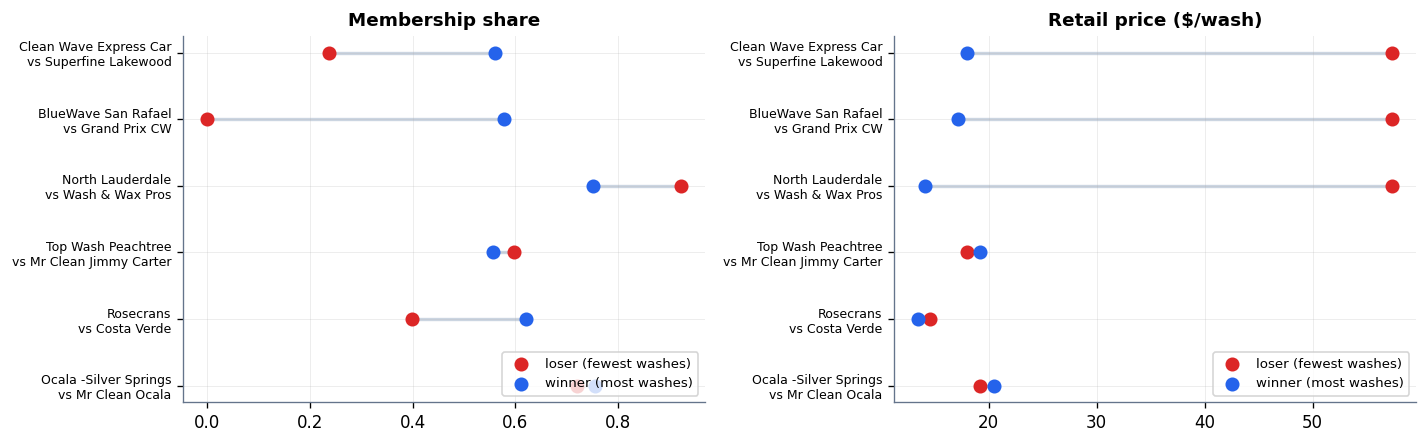

In [12]:
tw=df[(df.cl_size>=3)&(df.tenure_mo>=30)].copy(); rows=[]
for cl,gc in tw.groupby("cluster"):
    if len(gc)<3 or gc.annual_wash.min()<8000: continue
    w=gc.loc[gc.annual_wash.idxmax()]; l=gc.loc[gc.annual_wash.idxmin()]
    rows.append((cl,w.client_name[:22],l.client_name[:22],w.annual_wash,l.annual_wash,w.annual_wash/l.annual_wash,
                 w.mem_share,l.mem_share,w.asp_ret,l.asp_ret,w.population))
T=pd.DataFrame(rows,columns=["cl","winner","loser","win_wash","los_wash","x","win_mem","los_mem","win_asp","los_asp","pop"])
T=T.sort_values("x",ascending=False).head(6)
display(T.style.format({"win_wash":"{:,.0f}","los_wash":"{:,.0f}","x":"{:.1f}x","win_mem":"{:.0%}","los_mem":"{:.0%}",
                        "win_asp":"${:.0f}","los_asp":"${:.0f}","pop":"{:,.0f}"}).hide(axis="index"))

# dumbbell: winner vs loser on the two levers
fig,ax=plt.subplots(1,2,figsize=(12,3.8))
TT=T.head(6).iloc[::-1]; y=np.arange(len(TT))
for a_,wc,lc,title,fmt in [(ax[0],"win_mem","los_mem","Membership share","{:.0%}"),
                           (ax[1],"win_asp","los_asp","Retail price ($/wash)","${:.0f}")]:
    a_.hlines(y,TT[lc],TT[wc],color="#cbd5e1",lw=2,zorder=1)
    a_.scatter(TT[lc],y,color=C["lose"],s=55,zorder=2,label="loser (fewest washes)")
    a_.scatter(TT[wc],y,color=C["win"],s=55,zorder=2,label="winner (most washes)")
    a_.set_yticks(y); a_.set_yticklabels([f"{r.winner}\nvs {r.loser}" for _,r in TT.iterrows()],fontsize=7.5)
    a_.set_title(title); a_.legend(fontsize=8,loc="lower right")
plt.tight_layout(); plt.show()

Read the pairs: in most, the winner carries a **higher membership share** *and* a **lower retail
price** than the loser a few exits away — the losers are frequently the **high-price, thin-membership**
sites (several pinned at the top of the price range: the "$50 in a $20 town" pattern), washing a
fraction of the volume. The **instructive exception** is a loser with a *high* membership share that
still loses — it's running a **small member base**, exactly §7's point: what counts is member
*headcount*, not share.

## Summary — what we were missing

**The market is not destiny.** ~**60% of the variation in wash volume is *within* a 20 km market**,
not between markets. Two neighbours routinely differ **3×+**. Picking the metro is under half the battle.

Reading it level by level — the question asked whether it's population, traffic, vehicles, or regional
demand:

1. **Between regions — yes, "people wash more" in some regions** (§3). Per-person wash intensity swings
   **~10×**, Sun Belt / Mid-South ≫ coastal metros. But **demographics explain only ~7%** of it — it's
   a **latent wash culture**, not income/population/vehicles. Screen on *region first*; the census
   columns won't tell you which regions wash.
2. **Within a region — the market factors are shared, so they can't explain who wins** (§5). Population,
   vehicles, daily traffic, competitor distance ≈ 0 within a cluster; income barely registers (+0.12).
   The site-selection screen describes the *neighbourhood*, and the neighbourhood is common to winner
   and loser alike. **This is what we were missing.**
3. **Membership is the measurable separator** (ρ ≈ +0.56 within-market, §7) — specifically the **size
   of the member base**, not washing each member harder. Volume is a membership-*acquisition* game.
4. **Price is a weak lever, not a death trap** (§6). Charging above neighbours costs a little volume;
   revenue is volume-dominated. Real **pricing power** (high price *and* high volume, ~$220K/mo) is
   *earned* by a big member base — you don't set it on the sign. The "$50 in a $20 region, fewer washes"
   site is the thin-membership one.
5. **The single biggest lever is the operator** (§8). Same neighbourhood, different brand → **−60% to
   +100%** on volume, a bigger swing than any market factor; brands wash more alike than neighbourhoods
   do. Membership explains only ~⅓ of the brand edge — the rest is execution. Copy the top operators'
   playbook; don't just buy their kind of lot.

**Honest limits.** Membership holds as the separator on *every factor this data contains* — but it
explains ~40% of the within-market gap, and the missing ~60% is **physical capacity / throughput**
(tunnel length, vacuum stalls, pay-stations, staffing, marketing spend), which the panel barely
records. That's also a **live confound**: a bigger plant supports *both* more members and more washes,
so with the build specs in hand, "recruit members" vs "build bigger, faster tunnels" can't yet be
fully separated. The clear next step is to get tunnel/vacuum/pay-station specs onto the site table.
Everything above is decided by capability you *build* — not a location you *buy*.